# Phân loại Email Spam
## 7. Huấn luyện mô hình Naive Bayes

Chúng ta thực hiện tối ưu hóa siêu tham số và huấn luyện hai mô hình phân loại Multinomial Naive Bayes trên tập dữ liệu đã được tiền xử lý của giải pháp **`Navies_vqd`** (Tập dữ liệu sạch tối ưu):
1. Mô hình tự viết từ đầu: `NaiveBayesClassifierFromScratch`
2. Mô hình chuẩn từ thư viện: `MultinomialNB` của Scikit-learn

### Các tham số của mô hình Naive Bayes

| Tham số | Kiểu dữ liệu | Mặc định | Mô tả |
|-----------|------|---------|-------------|
| `alpha` | float | 1.0 | Hằng số làm mịn Laplace / Lidstone |
| `force_alpha` | bool | True | Ngăn cản alpha bị cắt về 1e-10 nếu giá trị thiết lập nhỏ hơn |
| `fit_prior` | bool | True | Tự động tính xác suất tiên nghiệm của các lớp từ dữ liệu train |
| `class_prior` | array hoặc None | None | Xác suất tiên nghiệm cố định do người dùng truyền vào (ghi đè `fit_prior`) |

### Cơ chế hoạt động của thuật toán Multinomial Naive Bayes

Bộ phân loại **Multinomial Naive Bayes** hoạt động dựa trên định lý Bayes với giả định "ngây thơ" về sự độc lập có điều kiện giữa các đặc trưng (từ khóa).

#### 1. Định lý Bayes tổng quát
Xác suất hậu nghiệm (posterior probability) của lớp $C_k$ sau khi quan sát vector đặc trưng văn bản $X = (x_1, x_2, \dots, x_n)$ được tính bằng công thức:
$$P(C_k | X) = \frac{P(X | C_k) P(C_k)}{P(X)}$$
Trong đó:
*   $P(C_k)$: Xác suất tiên nghiệm (prior probability) của lớp $C_k$.
*   $P(X | C_k)$: Xác suất hợp lệ (likelihood) của dữ liệu $X$ khi biết thuộc lớp $C_k$.
*   $P(X)$: Xác suất biên (marginal probability), đóng vai trò là hằng số chuẩn hóa và thường được bỏ qua khi tìm lớp có xác suất lớn nhất.

#### 2. Giả định độc lập Naive (Ngây thơ)
Naive Bayes giả định rằng sự xuất hiện của các từ trong văn bản là độc lập với nhau khi biết lớp $C_k$:
$$P(X | C_k) = P(x_1, x_2, \dots, x_n | C_k) = \prod_{i=1}^{n} P(x_i | C_k)$$
Với mô hình **Multinomial**, các đặc trưng $x_i$ đại diện cho tần suất xuất hiện (hoặc trọng số TF-IDF) của từ $w_i$ trong tài liệu. Xác suất hợp lệ của tài liệu được tính bằng phân phối đa thức:
$$P(X | C_k) \propto \prod_{i=1}^{n} P(w_i | C_k)^{x_i}$$

#### 3. Log-space để tránh lỗi tràn số dưới (Floating-point Underflow)
Khi nhân liên tiếp các xác suất nhỏ ($< 1.0$), máy tính sẽ gặp lỗi tràn số dưới (floating-point underflow) đưa xác suất về 0. Do đó, ta chuyển công thức sang không gian logarit (log-space):
$$\log P(C_k | X) \propto \log P(C_k) + \sum_{i=1}^{n} x_i \log P(w_i | C_k)$$
Hàm phân loại (prediction) sẽ chọn lớp có điểm số logarit lớn nhất:
$$\hat{y} = \arg\max_{C_k} \left( \log P(C_k) + \sum_{i=1}^{n} x_i \log P(w_i | C_k) \right)$$

#### 4. Làm mịn Laplace (Laplace Smoothing)
Nếu một từ $w_i$ chưa từng xuất hiện trong lớp $C_k$ ở tập huấn luyện, xác suất $P(w_i | C_k)$ sẽ bằng 0, kéo theo toàn bộ xác suất tích bằng 0. Để khắc phục, ta sử dụng kỹ thuật làm mịn Laplace (với tham số $\alpha$):
$$P(w_i | C_k) = \frac{N_{k, i} + \alpha}{N_k + \alpha \cdot V}$$
Trong đó:
*   $N_{k, i}$: Tổng tần suất (hoặc trọng số TF-IDF) của từ $w_i$ trong lớp $C_k$.
*   $N_k$: Tổng tần suất (hoặc trọng số TF-IDF) của tất cả các từ trong lớp $C_k$ ($N_k = \sum_{j=1}^{V} N_{k, j}$).
*   $V$: Kích thước từ vựng (tổng số đặc trưng).
*   $\alpha$: Hệ số làm mịn (thường là $1.0$ cho Laplace hoặc $< 1.0$ cho Lidstone).

#### 5. Chuẩn hóa xác suất dự đoán (Softmax ổn định số học)
Để xuất ra xác suất cụ thể cho từng lớp (phục vụ cho hàm `predict_proba`), ta áp dụng hàm Softmax trên các điểm số logarit $z_k = \log P(C_k | X)$. Để tránh lỗi tràn số trên (overflow) khi tính lũy thừa $e^z$, ta áp dụng Softmax ổn định số học bằng cách trừ đi giá trị cực đại:
$$P(C_k | X) = \frac{e^{z_k - \max(z)}}{\sum_{j} e^{z_j - \max(z)}}$$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import os
import sys
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Thêm root folder vào sys.path để import utils
sys.path.append(os.path.abspath(os.path.join('..')))
from practice_1.utils.custom_cv import CustomKFold
from practice_1.utils.custom_hyperparameter_tuning import CustomGridSearchCV

# Tải dữ liệu tự xử lý từ folder Navies_vqd
X_train = joblib.load('./Navies_vqd/data/ready_for_train/X_train_tfidf.pkl')
X_test = joblib.load('./Navies_vqd/data/ready_for_train/X_test_tfidf.pkl')
y_train = joblib.load('./Navies_vqd/data/ready_for_train/y_train.pkl')
y_test = joblib.load('./Navies_vqd/data/ready_for_train/y_test.pkl')

# Đảm bảo y là 1D array
if hasattr(y_train, 'values'):
    y_train = y_train.values.flatten()
else:
    y_train = np.array(y_train).flatten()

if hasattr(y_test, 'values'):
    y_test = y_test.values.flatten()
else:
    y_test = np.array(y_test).flatten()

print('Kích thước tập Train:', X_train.shape)
print('Kích thước tập Test :', X_test.shape)

Kích thước tập Train: (26932, 5000)
Kích thước tập Test : (6733, 5000)


### 7.1 Mô hình Naive Bayes viết từ đầu

In [2]:
class NaiveBayesClassifierFromScratch:
    """
    Bộ phân loại Multinomial Naive Bayes viết từ đầu.

    Parameters
    ----------
    alpha : float
        Hằng số làm mịn Laplace. Mặc định 1.0.
    force_alpha : bool
        Nếu False và alpha < 1e-10, alpha sẽ bị cắt về 1e-10 để tránh
        lỗi chia cho 0. Mặc định True (giữ nguyên alpha thiết lập).
    fit_prior : bool
        Nếu True, tính xác suất tiên nghiệm của các lớp từ dữ liệu huấn luyện.
        Nếu False, sử dụng phân phối đều. Mặc định True.
    class_prior : array-like hoặc None
        Mảng xác suất tiên nghiệm cố định do người dùng tự định nghĩa.
        Khi được gán, sẽ ghi đè cả fit_prior và phân phối từ dữ liệu. Mặc định None.
    """

    def __init__(self, alpha=1.0, force_alpha=True,
                 fit_prior=True, class_prior=None):
        self.alpha        = alpha
        self.force_alpha  = force_alpha
        self.fit_prior    = fit_prior
        self.class_prior  = class_prior
        self.classes_          = None
        self.class_priors_     = {}
        self.word_likelihoods_ = {}
        self.vocab_size_       = 0

    def get_params(self, deep=True):
        return {
            "alpha": self.alpha,
            "force_alpha": self.force_alpha,
            "fit_prior": self.fit_prior,
            "class_prior": self.class_prior
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes_    = np.unique(y)
        self.vocab_size_ = n_features

        # Xác định giá trị alpha áp dụng
        eff_alpha = self.alpha
        if not self.force_alpha and self.alpha < 1e-10:
            eff_alpha = 1e-10

        # Tính toán xác suất tiên nghiệm của các lớp
        if self.class_prior is not None:
            for idx, c in enumerate(self.classes_):
                self.class_priors_[c] = self.class_prior[idx]
        elif not self.fit_prior:
            uniform = 1.0 / len(self.classes_)
            for c in self.classes_:
                self.class_priors_[c] = uniform
        else:
            for c in self.classes_:
                self.class_priors_[c] = np.sum(y == c) / n_samples

        # Tính toán log-likelihood của các từ kèm làm mịn Laplace
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        for c in self.classes_:
            X_c    = X_arr[y == c]
            total  = X_c.sum()
            counts = X_c.sum(axis=0)
            self.word_likelihoods_[c] = (
                (counts + eff_alpha) /
                (total  + eff_alpha * self.vocab_size_)
            )
        return self

    def predict(self, X):
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        preds = []
        for row in X_arr:
            scores = {
                c: np.log(self.class_priors_[c]) +
                   np.sum(row * np.log(self.word_likelihoods_[c]))
                for c in self.classes_
            }
            preds.append(max(scores, key=scores.get))
        return np.array(preds)

    def predict_proba(self, X):
        """Tính xác suất tiên nghiệm sau khi quan sát dữ liệu (Softmax ổn định số học)."""
        X_arr = X.toarray() if hasattr(X, 'toarray') else np.array(X)
        proba = []
        for row in X_arr:
            log_scores = np.array([
                np.log(self.class_priors_[c]) +
                np.sum(row * np.log(self.word_likelihoods_[c]))
                for c in self.classes_
            ])
            # Softmax ổn định số học
            log_scores -= log_scores.max()
            exp_s = np.exp(log_scores)
            proba.append(exp_s / exp_s.sum())
        return np.array(proba)

print('Định nghĩa lớp NaiveBayesClassifierFromScratch thành công.')

Định nghĩa lớp NaiveBayesClassifierFromScratch thành công.


### 7.2 Huấn luyện và Tìm kiếm siêu tham số bằng Cross-Validation

In [3]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

results = {}
param_grid = {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}
cv = CustomKFold(n_splits=3, shuffle=True, random_state=42)

# --- From Scratch với GridSearchCV ---
print('--- Tối ưu hóa siêu tham số cho Naive Bayes From Scratch ---')
clf_scratch_base = NaiveBayesClassifierFromScratch(force_alpha=True, fit_prior=True)
grid_scratch = CustomGridSearchCV(
    estimator=clf_scratch_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1'
)

t0 = time.time()
grid_scratch.fit(X_train, y_train)
t_fit_s = time.time() - t0

clf_scratch = grid_scratch.best_estimator_

t0 = time.time()
y_pred_scratch = clf_scratch.predict(X_test)
y_prob_scratch = clf_scratch.predict_proba(X_test)[:, 1]
t_pred_s = time.time() - t0

results['From Scratch'] = {
    'accuracy':  accuracy_score(y_test, y_pred_scratch),
    'precision': precision_score(y_test, y_pred_scratch, pos_label='spam'),
    'recall':    recall_score(y_test, y_pred_scratch, pos_label='spam'),
    'f1':        f1_score(y_test, y_pred_scratch, pos_label='spam'),
    'fit_time':  t_fit_s,
    'pred_time': t_pred_s,
}
print(f"-> Tham số TỐT NHẤT: {grid_scratch.best_params_}")
print(f"-> Điểm f1 TỐT NHẤT: {grid_scratch.best_score_:.4f}")

# --- Scikit-learn với GridSearchCV ---
print('\n--- Tối ưu hóa siêu tham số cho Scikit-learn MultinomialNB ---')
clf_sklearn_base = MultinomialNB(fit_prior=True)
grid_sklearn = CustomGridSearchCV(
    estimator=clf_sklearn_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1'
)

t0 = time.time()
grid_sklearn.fit(X_train, y_train)
t_fit_sk = time.time() - t0

clf_sklearn = grid_sklearn.best_estimator_

t0 = time.time()
y_pred_sklearn = clf_sklearn.predict(X_test)
y_prob_sklearn = clf_sklearn.predict_proba(X_test)[:, 1]
t_pred_sk = time.time() - t0

results['Scikit-learn'] = {
    'accuracy':  accuracy_score(y_test, y_pred_sklearn),
    'precision': precision_score(y_test, y_pred_sklearn, pos_label='spam'),
    'recall':    recall_score(y_test, y_pred_sklearn, pos_label='spam'),
    'f1':        f1_score(y_test, y_pred_sklearn, pos_label='spam'),
    'fit_time':  t_fit_sk,
    'pred_time': t_pred_sk,
}
print(f"-> Tham số TỐT NHẤT: {grid_sklearn.best_params_}")
print(f"-> Điểm f1 TỐT NHẤT: {grid_sklearn.best_score_:.4f}")

--- Tối ưu hóa siêu tham số cho Naive Bayes From Scratch ---
Bắt đầu GridSearchCV: 9 tổ hợp tham số, 3 folds.


[1/9] Params: {'alpha': 0.001} --> f1: 0.9815


[2/9] Params: {'alpha': 0.01} --> f1: 0.9812


[3/9] Params: {'alpha': 0.05} --> f1: 0.9810


[4/9] Params: {'alpha': 0.1} --> f1: 0.9806


...

[6/9] Params: {'alpha': 1.0} --> f1: 0.9799


[7/9] Params: {'alpha': 2.0} --> f1: 0.9791


[8/9] Params: {'alpha': 5.0} --> f1: 0.9788


[9/9] Params: {'alpha': 10.0} --> f1: 0.9779

-> Tham số TỐT NHẤT: {'alpha': 0.001}
-> Điểm f1 TỐT NHẤT: 0.9815


-> Tham số TỐT NHẤT: {'alpha': 0.001}
-> Điểm f1 TỐT NHẤT: 0.9815


### 7.3 Tóm tắt hiệu năng trên tập kiểm thử

In [4]:
summary = pd.DataFrame(results).T
summary[['accuracy', 'precision', 'recall', 'f1']] *= 100
summary = summary.rename(columns={
    'accuracy':  'Accuracy (%)',
    'precision': 'Precision (%)',
    'recall':    'Recall (%)',
    'f1':        'F1 (%)',
    'fit_time':  'Thời gian Fit (s)',
    'pred_time': 'Thời gian Dự đoán (s)',
})
print(summary.round(4).to_string())

              Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  Thời gian Fit (s)  Thời gian Dự đoán (s)
From Scratch        98.292        98.4764       98.16  98.318            16.4741                 0.4816
Scikit-learn        98.292        98.4764       98.16  98.318            11.0735                 0.1251


### 7.4 Trực quan hóa Đánh giá Mô hình (Confusion Matrix & ROC Curve)

Mô hình Naive Bayes tốt nhất đã được lưu tại ./models/Naive_Bayes_Scratch.pkl


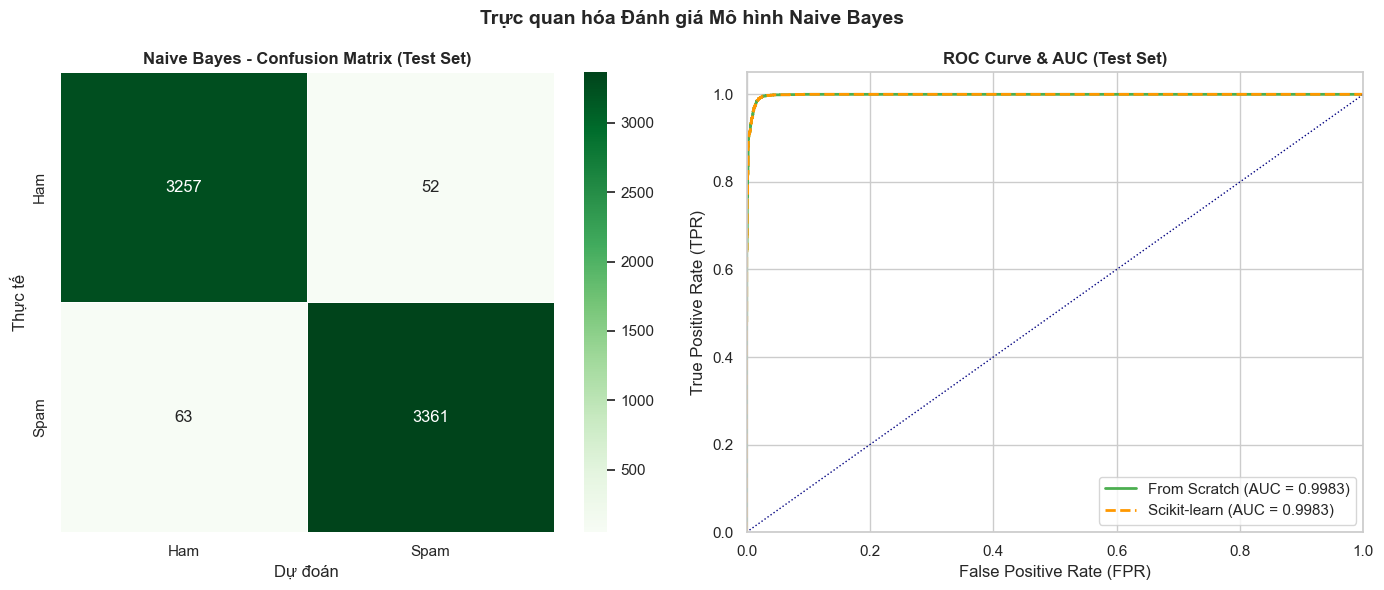

In [5]:
# Khởi tạo hình vẽ có 2 biểu đồ trực quan (Confusion Matrix & ROC-AUC)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Trực quan hóa Confusion Matrix (lấy từ mô hình Scikit-learn đại diện, nhãn 'ham'/'spam')
cm_sk = confusion_matrix(y_test, y_pred_sklearn, labels=['ham', 'spam'])
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            edgecolor='black', linewidths=0.5, ax=axes[0])
axes[0].set_title('Naive Bayes - Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

# 2. Trực quan hóa ROC Curve & AUC (lớp dương 'spam')
fpr_scr, tpr_scr, _ = roc_curve(y_test, y_prob_scratch, pos_label='spam')
auc_scr = auc(fpr_scr, tpr_scr)

fpr_sk, tpr_sk, _ = roc_curve(y_test, y_prob_sklearn, pos_label='spam')
auc_sk = auc(fpr_sk, tpr_sk)

axes[1].plot(fpr_scr, tpr_scr, color='#4CAF50', lw=2, label=f'From Scratch (AUC = {auc_scr:.4f})')
axes[1].plot(fpr_sk, tpr_sk, color='#FF9800', lw=2, linestyle='--', label=f'Scikit-learn (AUC = {auc_sk:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('ROC Curve & AUC (Test Set)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

plt.suptitle('Trực quan hóa Đánh giá Mô hình Naive Bayes', fontsize=14, fontweight='bold')
plt.tight_layout()

# Tạo thư mục models và lưu mô hình
os.makedirs('./models', exist_ok=True)
joblib.dump(clf_scratch, './models/Naive_Bayes_Scratch.pkl')
print("Mô hình Naive Bayes tốt nhất đã được lưu tại ./models/Naive_Bayes_Scratch.pkl")
plt.show()